<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_9/Day_2/Daily_challenge%20/Daily_challenge_w9_d2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge: Data Cleaning and Transformation with Real-World Datasets
===

## 1. Data Cleaning:
* Initial Assessment: Load the dataset and conduct a preliminary assessment to understand its structure and content.
* Handling Inconsistencies: Identify and address missing values, incorrect data types, and data inconsistencies.


## 2. Data Transformation:
* Categorical Transformation: Convert categorical data into a format suitable for analysis, such as one-hot encoding.
* Numerical Normalization: Normalize or standardize numerical features as required.


## 3. Exploratory Data Analysis:
* Data Exploration: Conduct exploratory data analysis on the cleaned and integrated dataset.
* Visualization: Create visualizations to reveal patterns and insights related to terrorism events in their socio-economic context.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Data Cleaning:

In [2]:

print("Loading dataset... This might take a moment...")
df = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='ISO-8859-1')

columns_to_keep = ['iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'nkill', 'nwound']
df_clean = df[columns_to_keep].copy()

df_clean.columns = ['Year', 'Month', 'Day', 'Country', 'Region', 'AttackType', 'TargetType', 'Killed', 'Wounded']

df_clean['Killed'] = df_clean['Killed'].fillna(0).astype(int)
df_clean['Wounded'] = df_clean['Wounded'].fillna(0).astype(int)

print("Initial Clean Complete! Current shape:", df_clean.shape)
df_clean.head()

Loading dataset... This might take a moment...


/tmp/ipykernel_10599/4041793052.py:2: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='ISO-8859-1')


Initial Clean Complete! Current shape: (181691, 9)


,Year,Month,Day,Country,Region,AttackType,TargetType,Killed,Wounded
0,1970,7,2,Dominican Republic,Central America & Caribbean,Assassination,Private Citizens & Property,1,0
1,1970,0,0,Mexico,North America,Hostage Taking (Kidnapping),Government (Diplomatic),0,0
2,1970,1,0,Philippines,Southeast Asia,Assassination,Journalists & Media,1,0
3,1970,1,0,Greece,Western Europe,Bombing/Explosion,Government (Diplomatic),0,0
4,1970,1,0,Japan,East Asia,Facility/Infrastructure Attack,Government (Diplomatic),0,0


## Data Transformation:

In [3]:
top_attacks = df_clean['AttackType'].value_counts().index[:5]
for attack in top_attacks:
    df_clean[f'Attack_{attack}'] = np.where(df_clean['AttackType'] == attack, 1, 0)

scaler = StandardScaler()
df_clean[['Killed_Scaled', 'Wounded_Scaled']] = scaler.fit_transform(df_clean[['Killed', 'Wounded']])

print("Transformation Complete! Sample of One-Hot Columns:")
df_clean[[f'Attack_{a}' for a in top_attacks]].head()

Transformation Complete! Sample of One-Hot Columns:


,Attack_Bombing/Explosion,Attack_Armed Assault,Attack_Assassination,Attack_Hostage Taking (Kidnapping),Attack_Facility/Infrastructure Attack
0,0,0,1,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,1,0,0,0,0
4,0,0,0,0,1


## Exploratory Data Analysis:

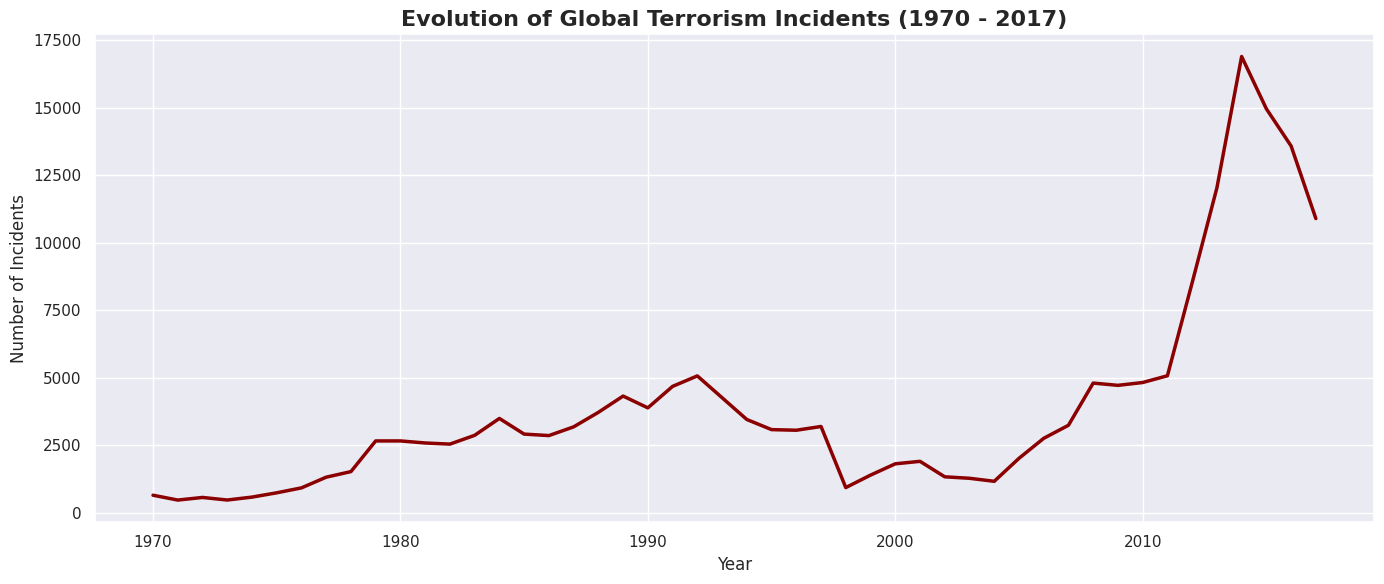

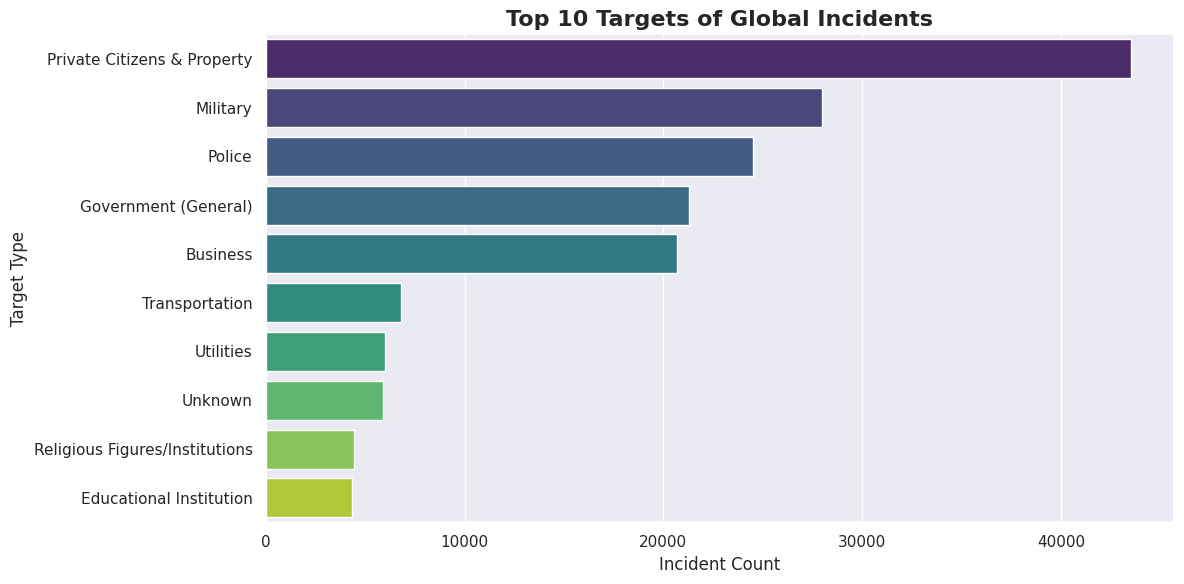

In [5]:
sns.set_theme(style="darkgrid")

# Visualization 1: Global Incidents Over the Years
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_clean['Year'].value_counts().sort_index(), linewidth=2.5, color='darkred')
plt.title('Evolution of Global Terrorism Incidents (1970 - 2017)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 2: Top Target Types Affected
plt.figure(figsize=(12, 6))
top_targets = df_clean['TargetType'].value_counts().head(10)
sns.barplot(x=top_targets.values, y=top_targets.index, hue=top_targets.index, palette='viridis', legend=False)
plt.title('Top 10 Targets of Global Incidents', fontsize=16, fontweight='bold')
plt.xlabel('Incident Count', fontsize=12)
plt.ylabel('Target Type', fontsize=12)
plt.tight_layout()
plt.show()

# Analysis of Findings: Evolution of Global Incidents (Line Chart)
The line graph illustrates the temporal trajectory of registered global incidents from 1970 through 2017. The data reveals a relatively stable baseline of low to moderate activity spanning from the 1970s through the early 2000s, punctuated by a minor peak around the early 1990s. However, the most striking historical pattern begins post-2010, showing an exponential surge in global incidents that peaks dramatically around 2014. This sharp upward trend highlights a highly volatile geopolitical climate during that decade. Following the 2014 peak, the line begins a steep decline, indicating a significant contraction in recorded events toward the end of the data tracking period in 2017.

_____

#Analysis of Findings: Target Breakdown (Bar Chart)
The horizontal bar chart provides a structural breakdown of the top ten target categories affected by these events, ordered by total incident volume. The data reveals that Private Citizens & Property represent the most vulnerable category by a wide margin, experiencing over 40,000 recorded incidents. This is followed closely by institutional groups tasked with state security and infrastructure maintenance, specifically the Military, Police, and Government (General) bodies, which all cluster significantly above the 20,000 incident threshold. In contrast, civilian infrastructure and foundational entities such as Transportation, Utilities, and Educational Institutions reflect lower overall frequencies, sitting below the 10,000 count mark. This stark distribution implies that strategic impacts heavily favor soft targets (private citizens) and direct state representation (military and law enforcement).